---
title: "Visualizing Simple Trajectories as Funnel Polygons"
author: "Insang Song"
date: "2026-04-14"
categories: [spatial, R, geospatial]
---

## Overview

This post demonstrates a novel approach for visualizing a two-point segment (trajectory) as a funnel-shaped polygon. Rather than representing a tornado as a simple line from start to end point, this method creates a polygon where the width expands or contracts based on observed phenomena intensity at each point along the path.

## The Function

The `conv_point_trajectory()` function converts two points (start/end of a tornado path) into a funnel-shaped polygon. It works by:

1. Densifying the line between start and end points at regular intervals
2. Creating buffers around each densified point with radii that interpolate between start and end widths
3. Optionally applying a custom function to modify the radius along the trajectory
4. Aggregating all buffers into a single polygon representing the funnel

In [1]:
library(terra)

terra 1.9.1



In [2]:
conv_point_trajectory <-
  function(
    start_point = numeric(2),
    end_point = numeric(2),
    interval = 1e2,
    wd_start = numeric(1),
    wd_end = numeric(1),
    fun = NULL
  ) {
    start_point <-
      terra::vect(
        matrix(start_point, nrow = 1),
        crs = "EPSG:4326",
        type = "points"
      )
    end_point <-
      terra::vect(
        matrix(end_point, nrow = 1),
        crs = "EPSG:4326",
        type = "points"
      )
    spatvector <- terra::vect(c(start_point, end_point))
    line <- terra::as.lines(spatvector)
    line$id <- 1
    linedens <- terra::densify(line, interval)
    linedensp <- terra::as.points(linedens)
    radius <- seq(wd_start, wd_end, length.out = nrow(linedensp))
    if (!is.null(fun)) {
      radius <- fun(seq_along(radius))
    }
    linedenspb <-
      terra::buffer(
        linedensp,
        radius,
        quadsegs = 90L
      )
    linedenspbm <- terra::aggregate(linedenspb)
    return(linedenspbm)
  }

In [9]:
start_point <- c(-80, 35)
end_point <- c(-79.7, 35.3)
interval <- 1e2

trajpoly1 <- conv_point_trajectory(start_point, end_point, interval, 1000, 10000)


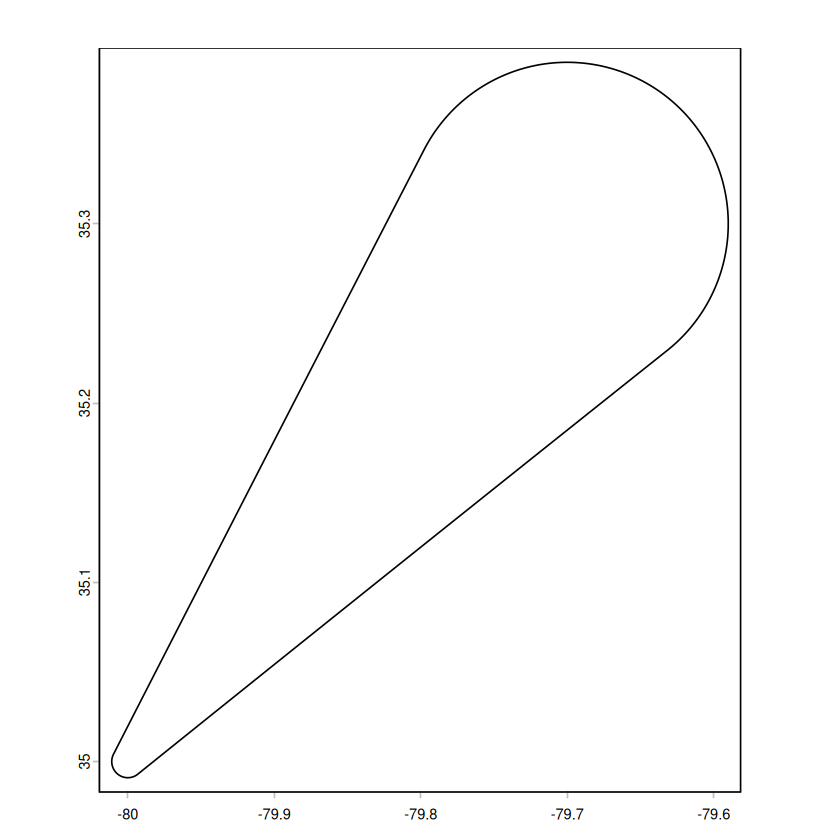

In [10]:
plot(trajpoly1)

## Example: Tornado Trajectories

Below are simulated extreme weather events in the United States. We use these to create visualizations of the funnel-shaped polygons representing the tornado paths with varying intensities.

In [ ]:
# Simulated trajectory data
# Event 1: near Kansas
event1_start <- c(-98.5, 38.8)
event1_end <- c(-98.2, 38.95)

# Event 2: near Oklahoma
event2_start <- c(-97.3, 35.4)
event2_end <- c(-97.0, 35.6)

# Event 3: near Nebraska
event3_start <- c(-103.8, 40.2)
event3_end <- c(-103.5, 40.4)

# Event 1: Narrow start (200m), wide end (4000m) - intensifying
t1 <- conv_point_trajectory(
  event1_start, event1_end,
  interval = 100,
  wd_start = 200,
  wd_end = 4000
)

# Event 2: Moderate widths with custom function
# Width increases more rapidly in the middle of the path
t2 <- conv_point_trajectory(
  event2_start, event2_end,
  interval = 100,
  wd_start = 200,
  wd_end = 3200,
  fun = function(x) 3200 * (1.2 - 0.25*cos(pi * (x + 0.01 ) / 60)) / 2
)

# Event 3: Widening
t3 <- conv_point_trajectory(
  event3_start, event3_end,
  interval = 100,
  wd_start = 4000,
  wd_end = 15000
)

## Visualizing the Trajectories

Now we plot all three funnel polygons on a single map to show their geographic extent and relative widths.

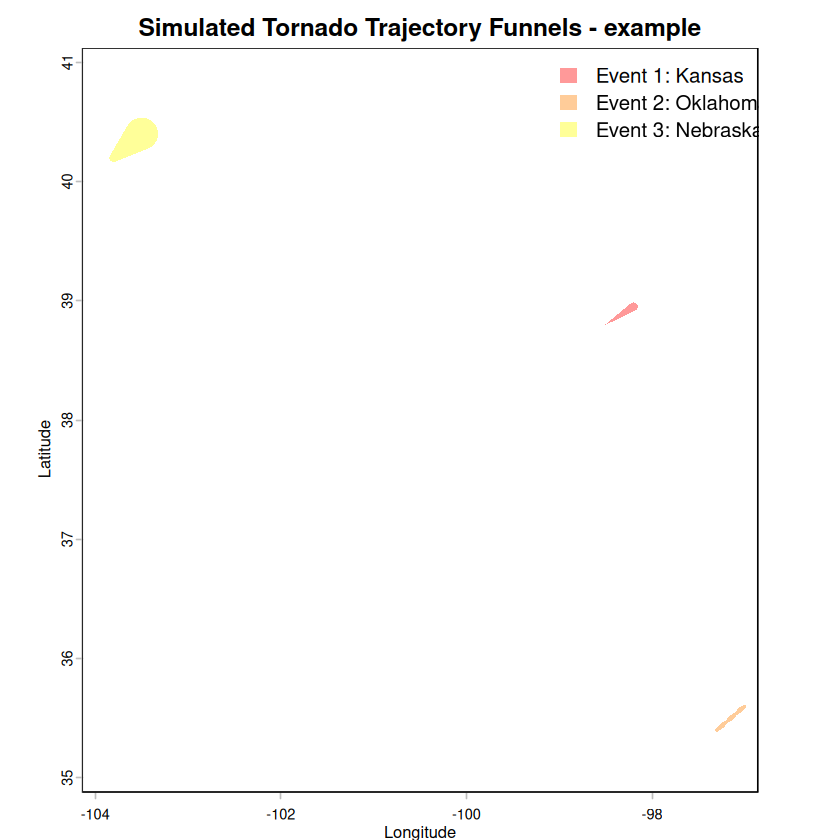

In [22]:
# Plot all trajectories
par(mar = c(4, 4, 2, 1), bg = "white")

# Plot each one with different colors
plot(
  t1,
  col = rgb(1, 0, 0, 0.4),
  border = NA,
  xlim = c(-104, -97),
  ylim = c(35, 41),
  main = "Simulated Tornado Trajectory Funnels - example",
  xlab = "Longitude",
  ylab = "Latitude"
)

# Add tornado 2
plot(t2, col = rgb(1, 0.5, 0, 0.4), border = NA, add = TRUE)

# Add tornado 3
plot(t3, col = rgb(1, 1, 0, 0.4), border = NA, add = TRUE)

# Add legend
legend(
  "topright",
  legend = c("Event 1: Kansas", "Event 2: Oklahoma", "Event 3: Nebraska"),
  fill = c(rgb(1, 0, 0, 0.4), rgb(1, 0.5, 0, 0.4), rgb(1, 1, 0, 0.4)),
  border = NA,
  bty = "n"
)

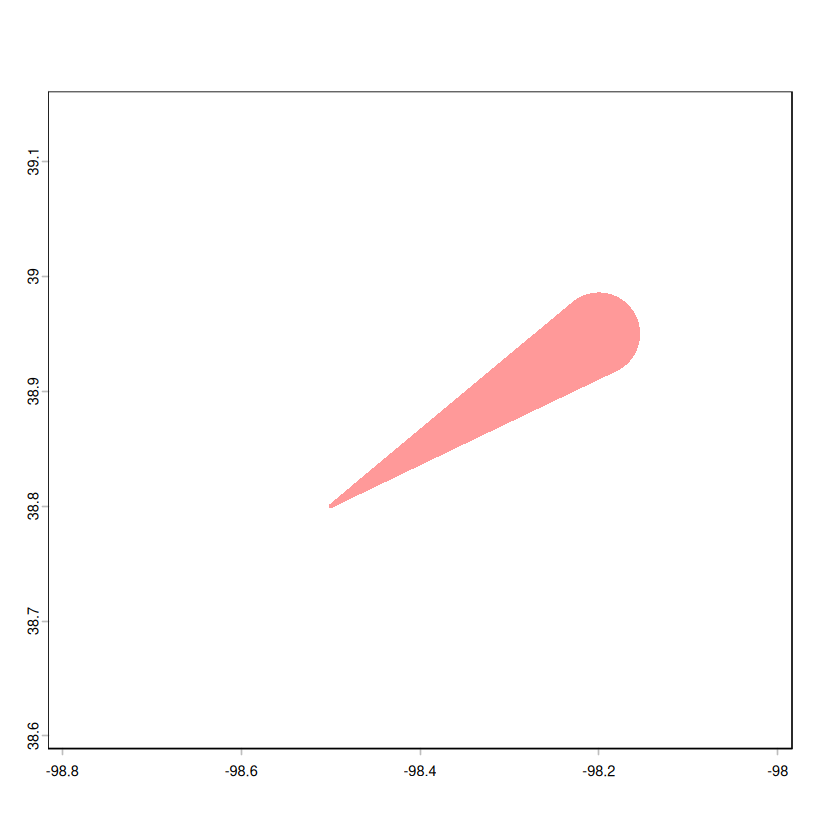

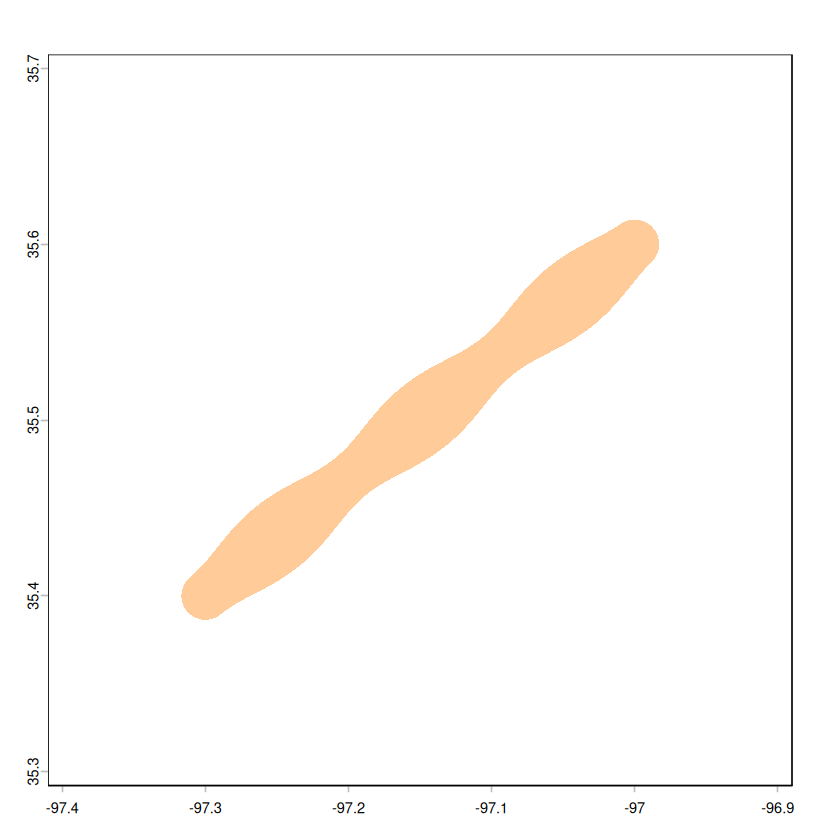

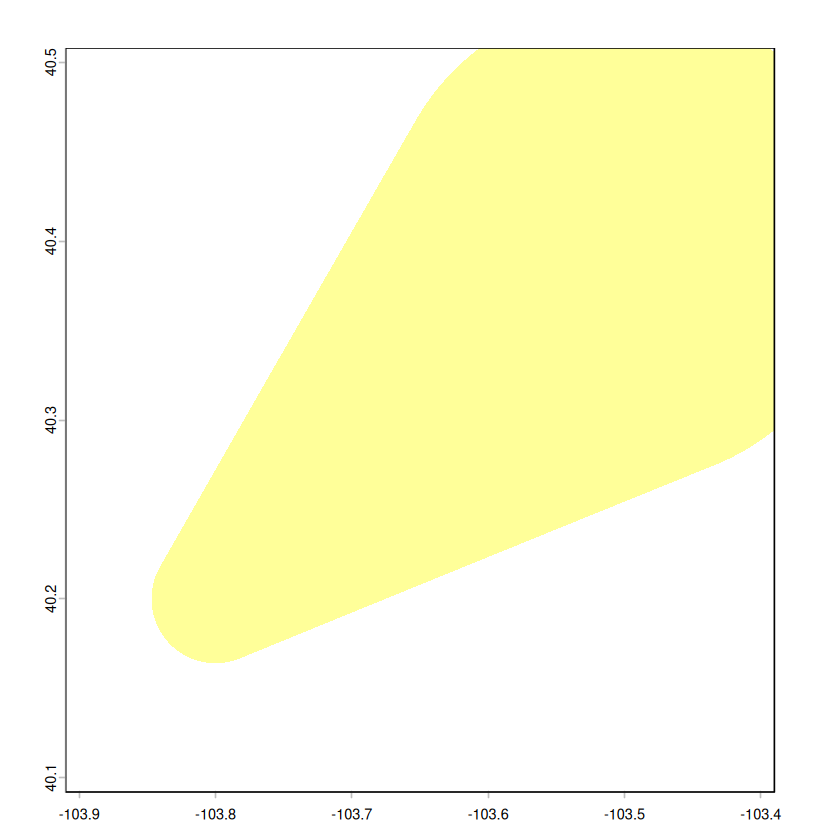

In [21]:
# zoom in on each event
plot(t1, col = rgb(1, 0, 0, 0.4), border = NA, xlim = c(-98.8, -98.0), ylim = c(38.6, 39.15))
plot(t2, col = rgb(1, 0.5, 0, 0.4), border = NA, xlim = c(-97.4, -96.9), ylim = c(35.3, 35.7))
plot(t3, col = rgb(1, 1, 0, 0.4), border = NA, xlim = c(-103.9, -103.4), ylim = c(40.1, 40.5))

## Key Insights

1. **Visual Impact**: The funnel representation immediately conveys both the path and intensity of the extreme weather event, such as tornado, especially when the limited observations are available.

2. **Customizable Width Functions**: Beyond linear interpolation, you can apply custom functions to model real-world phenomena:
   - Intensifying ones that start small
   - Peak-intensity patterns (bell curve)
   - Logarithmic or exponential growth patterns

3. **Comparison**: Multiple events can be overlaid to compare their geographic impact and path characteristics.

4. **Spatial Analysis**: These polygons can be used for subsequent spatial analysis operations like intersection with populated areas, land-use analysis, or risk assessment.